In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [2]:
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")
df = pd.read_csv(os.path.join(path, "zomato.csv"))
print("Raw shape:", df.shape)

Raw shape: (51717, 17)


In [3]:
# Drop irrelevant columns
df = df.drop(['url', 'phone', 'dish_liked', 'reviews_list', 'menu_item', 'address'], axis=1)

# Clean rate column
def clean_rate(value):
    if value in ('NEW', '-') or pd.isnull(value):
        return np.nan
    return float(str(value).split('/')[0])

df['rate'] = df['rate'].apply(clean_rate)

# Clean cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(
    lambda x: float(str(x).replace(',', '')) if pd.notnull(x) else np.nan
)

# Handle missing values
df = df.dropna(subset=['location', 'cuisines'], axis=0)
df['rest_type'] = df['rest_type'].fillna('Unknown')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].median()
)

# Rename columns
df = df.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)'            : 'type',
    'listed_in(city)'            : 'city'
})

# Verify
print("Cleaned shape:", df.shape)
print("Rate dtype:", df['rate'].dtype)
print("Missing values:\n", df.isnull().sum())

Cleaned shape: (51672, 11)
Rate dtype: float64
Missing values:
 name                0
online_order        0
book_table          0
rate            10018
votes               0
location            0
rest_type           0
cuisines            0
cost                0
type                0
city                0
dtype: int64


C:\Users\ashis\AppData\Local\Temp\ipykernel_12768\57628320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')


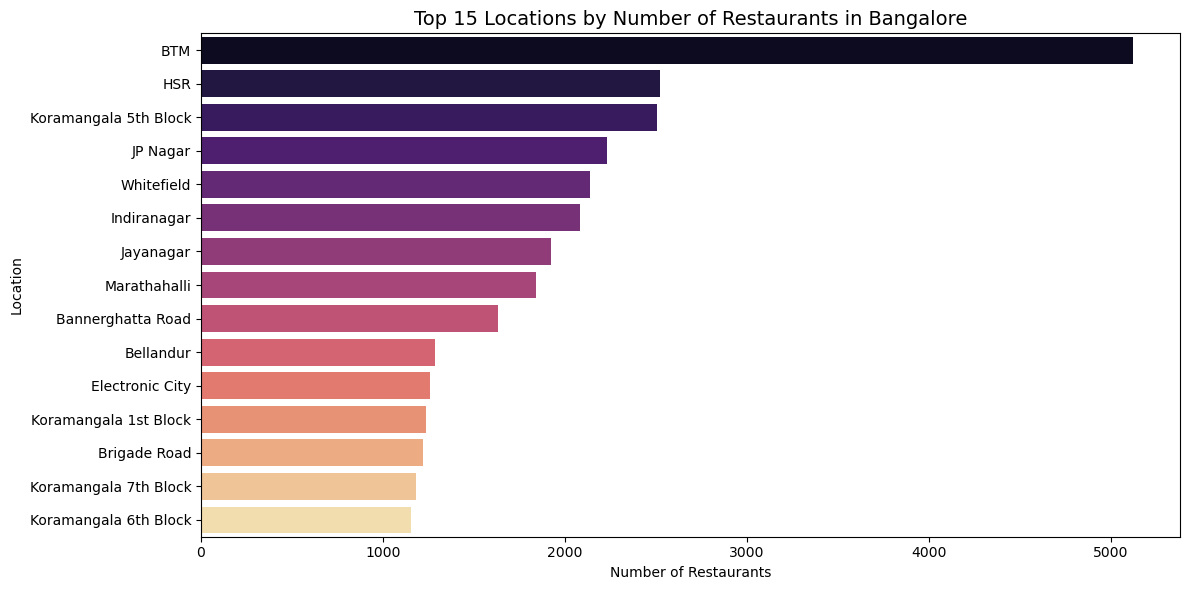

In [4]:
# Count restaurants per location, take top 15
top_locations = df['location'].value_counts().head(15)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')

plt.title('Top 15 Locations by Number of Restaurants in Bangalore', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

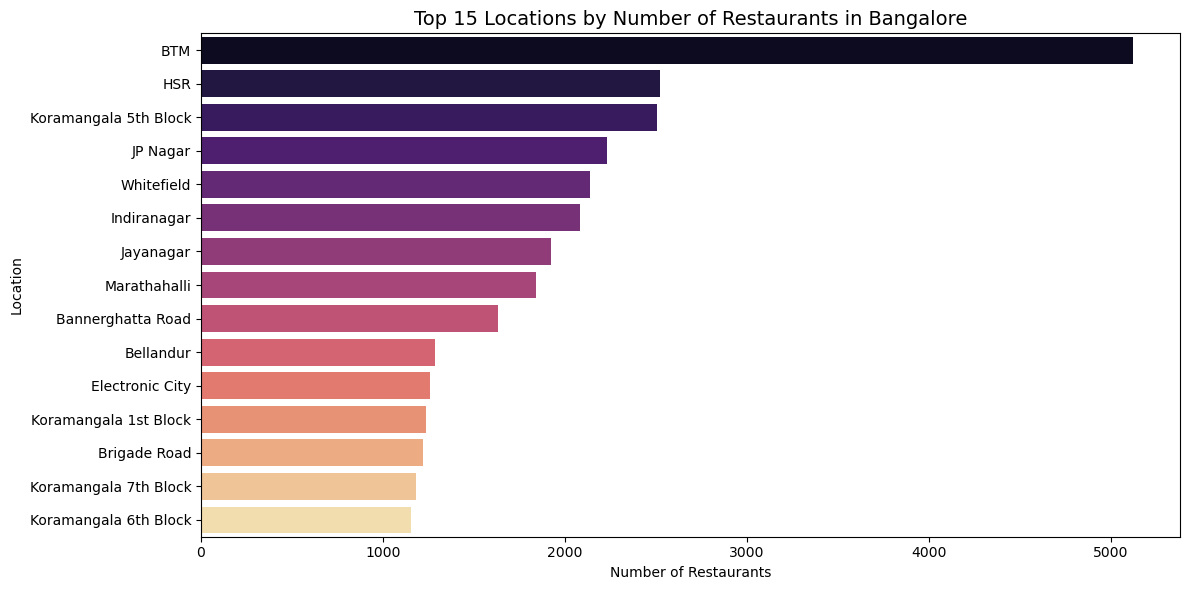

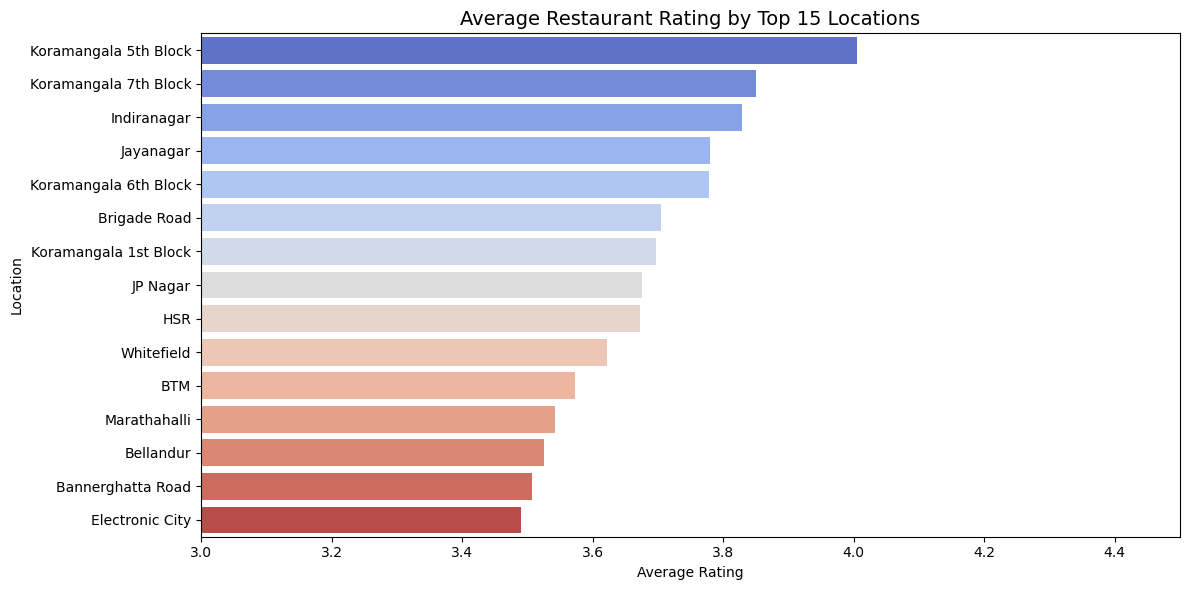

In [5]:
# Fix the palette warning by updating the barplot syntax
top_locations = df['location'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, 
            hue=top_locations.index, palette='magma', legend=False)

plt.title('Top 15 Locations by Number of Restaurants in Bangalore', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

# Now plot average rating for those same top 15 locations
top_location_names = top_locations.index.tolist()

avg_rating_by_location = (df[df['location'].isin(top_location_names)]
                            .groupby('location')['rate']
                            .mean()
                            .sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rating_by_location.values, 
            y=avg_rating_by_location.index,
            hue=avg_rating_by_location.index,
            palette='coolwarm', legend=False)

plt.title('Average Restaurant Rating by Top 15 Locations', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.xlim(3.0, 4.5)
plt.tight_layout()
plt.show()

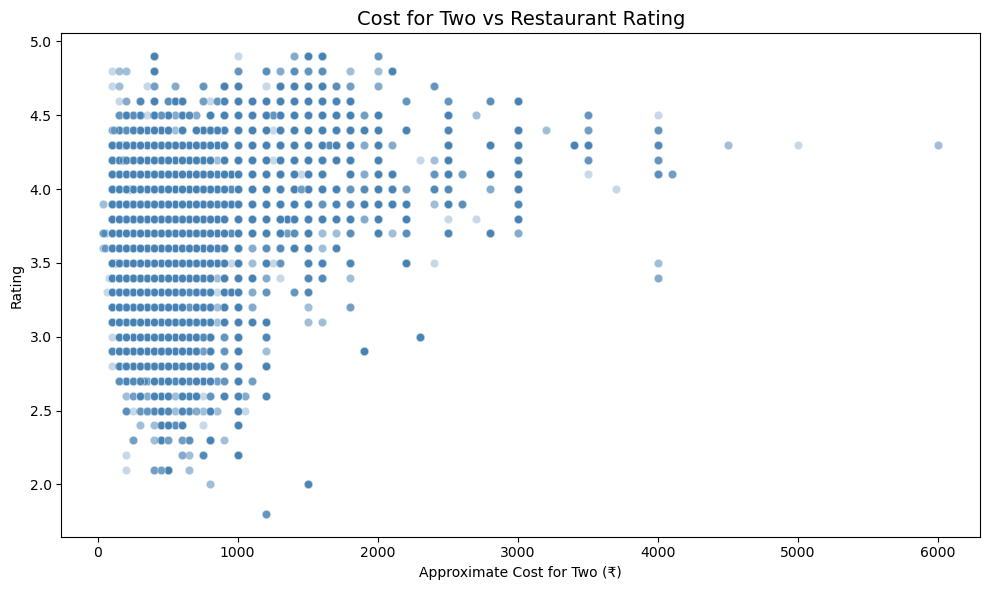

Pearson Correlation between Cost and Rating: 0.38


In [6]:
# Filter out rows where rate is missing for this question
df_rated = df.dropna(subset=['rate'])

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rated, x='cost', y='rate', alpha=0.3, color='steelblue')

plt.title('Cost for Two vs Restaurant Rating', fontsize=14)
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

# Correlation coefficient
correlation = df_rated['cost'].corr(df_rated['rate'])
print(f"Pearson Correlation between Cost and Rating: {correlation:.2f}")

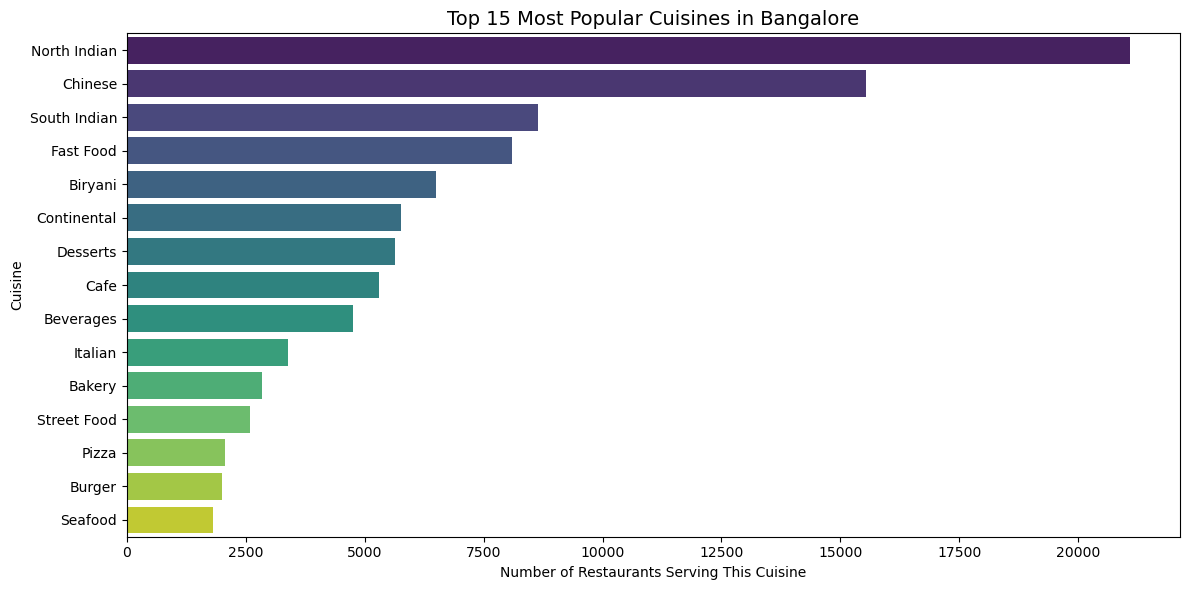

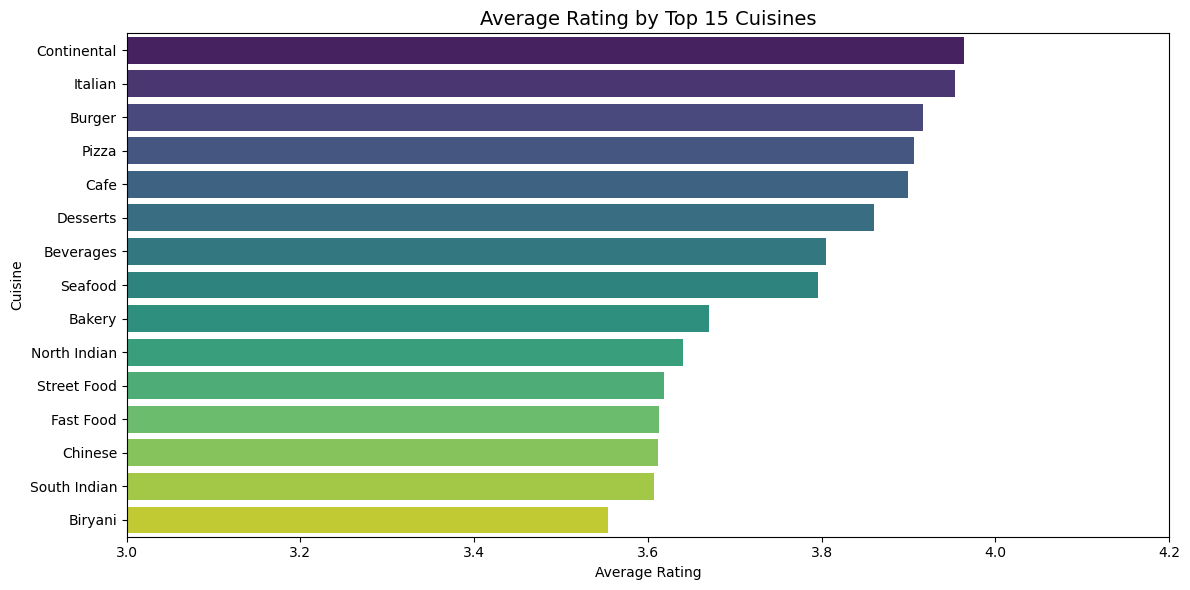

In [7]:
# Top 15 cuisines by count
cuisine_series = df['cuisines'].str.split(', ').explode()
top_cuisines = cuisine_series.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index,
            hue=top_cuisines.index, palette='viridis', legend=False)
plt.title('Top 15 Most Popular Cuisines in Bangalore', fontsize=14)
plt.xlabel('Number of Restaurants Serving This Cuisine')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

# Average rating per cuisine
top_cuisine_names = top_cuisines.index.tolist()

df_cuisine = df[['cuisines', 'rate']].dropna(subset=['rate']).copy()

# Confirm rate is numeric before exploding
df_cuisine['rate'] = pd.to_numeric(df_cuisine['rate'], errors='coerce')

df_cuisine['cuisines'] = df_cuisine['cuisines'].str.split(', ')
df_cuisine = df_cuisine.explode('cuisines')

avg_rating_cuisine = (df_cuisine[df_cuisine['cuisines'].isin(top_cuisine_names)]
                      .groupby('cuisines')['rate']
                      .mean()
                      .sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rating_cuisine.values,
            y=avg_rating_cuisine.index,
            hue=avg_rating_cuisine.index,
            palette='viridis', legend=False)
plt.title('Average Rating by Top 15 Cuisines', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.xlim(3.0, 4.2)
plt.tight_layout()
plt.show()

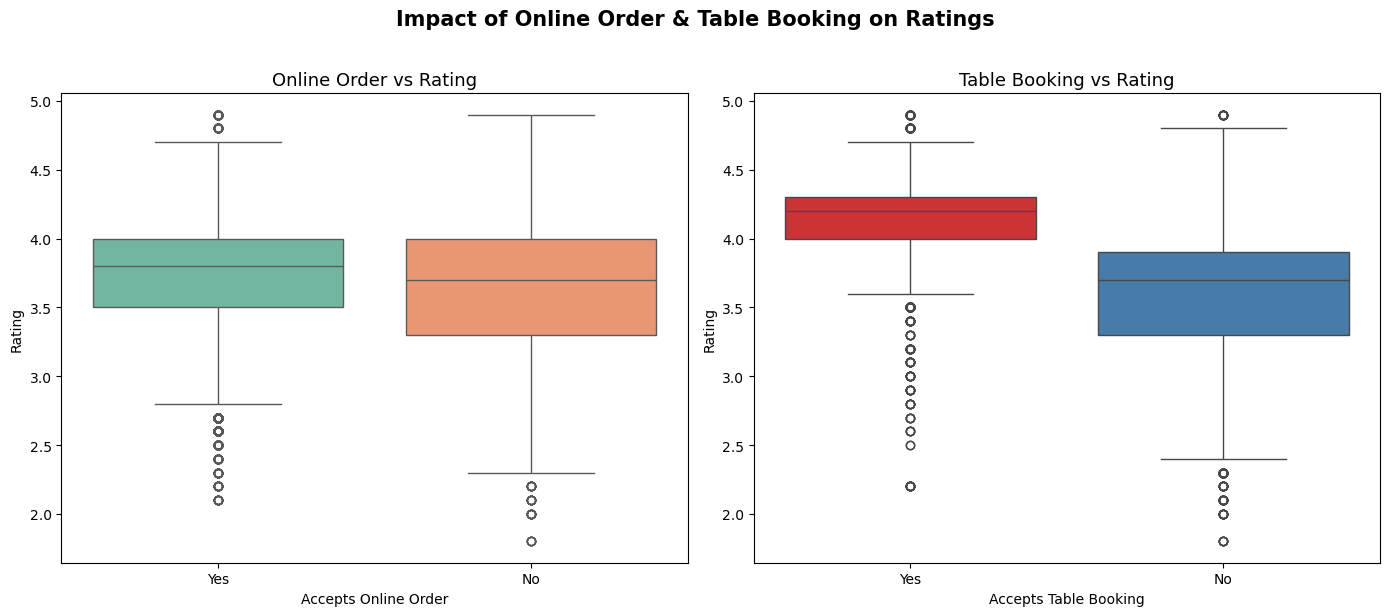

Mean rating by Online Order:
online_order
No     3.66
Yes    3.72
Name: rate, dtype: float64

Mean rating by Book Table:
book_table
No     3.62
Yes    4.14
Name: rate, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Online Order vs Rating
sns.boxplot(data=df.dropna(subset=['rate']),
            x='online_order', y='rate',
            hue='online_order', palette='Set2',
            legend=False, ax=axes[0])
axes[0].set_title('Online Order vs Rating', fontsize=13)
axes[0].set_xlabel('Accepts Online Order')
axes[0].set_ylabel('Rating')

# Plot 2: Book Table vs Rating
sns.boxplot(data=df.dropna(subset=['rate']),
            x='book_table', y='rate',
            hue='book_table', palette='Set1',
            legend=False, ax=axes[1])
axes[1].set_title('Table Booking vs Rating', fontsize=13)
axes[1].set_xlabel('Accepts Table Booking')
axes[1].set_ylabel('Rating')

plt.suptitle('Impact of Online Order & Table Booking on Ratings', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print mean ratings for exact numbers
print("Mean rating by Online Order:")
print(df.groupby('online_order')['rate'].mean().round(2))
print("\nMean rating by Book Table:")
print(df.groupby('book_table')['rate'].mean().round(2))

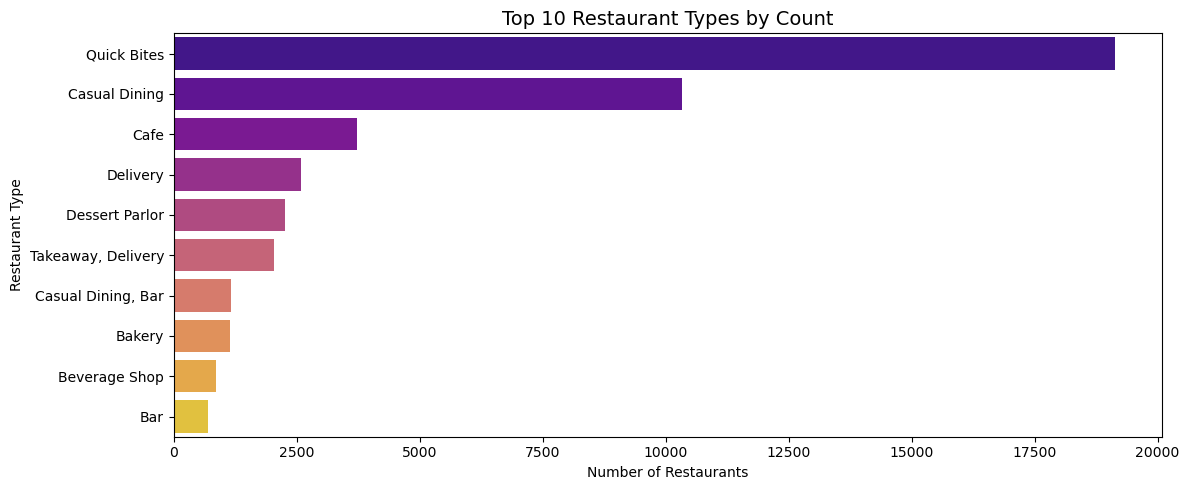

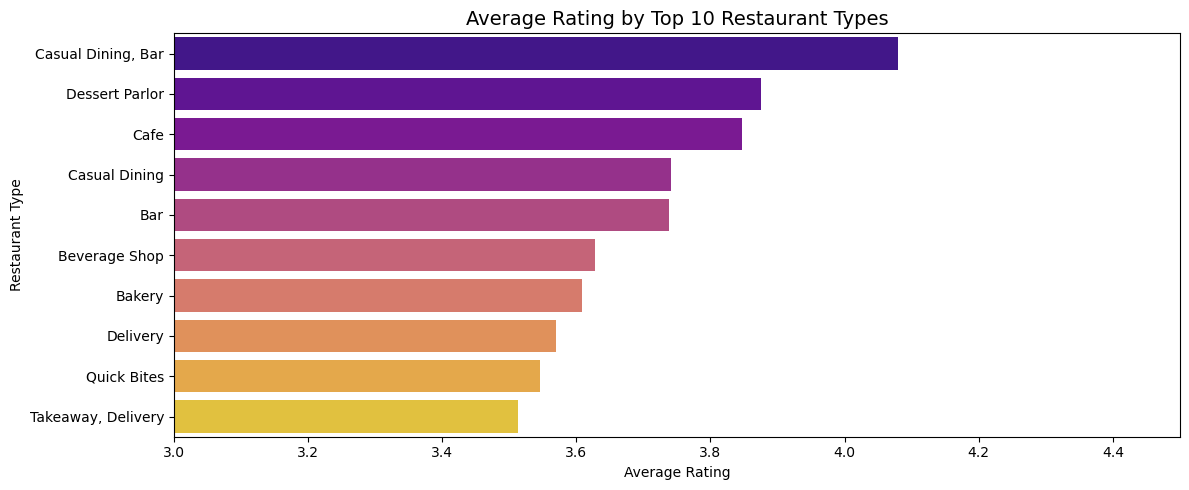

Mean rating by restaurant type:
rest_type
Casual Dining, Bar    4.08
Dessert Parlor        3.88
Cafe                  3.85
Casual Dining         3.74
Bar                   3.74
Beverage Shop         3.63
Bakery                3.61
Delivery              3.57
Quick Bites           3.55
Takeaway, Delivery    3.51
Name: rate, dtype: float64


In [9]:
# Top 10 restaurant types by count
top_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_types.values, y=top_types.index,
            hue=top_types.index, palette='plasma', legend=False)
plt.title('Top 10 Restaurant Types by Count', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.show()

# Average rating by those top 10 types
top_type_names = top_types.index.tolist()

avg_rating_type = (df[df['rest_type'].isin(top_type_names)]
                   .dropna(subset=['rate'])
                   .groupby('rest_type')['rate']
                   .mean()
                   .sort_values(ascending=False))

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_rating_type.values, y=avg_rating_type.index,
            hue=avg_rating_type.index, palette='plasma', legend=False)
plt.title('Average Rating by Top 10 Restaurant Types', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.xlim(3.0, 4.5)
plt.tight_layout()
plt.show()

# Print exact numbers
print("Mean rating by restaurant type:")
print(avg_rating_type.round(2))

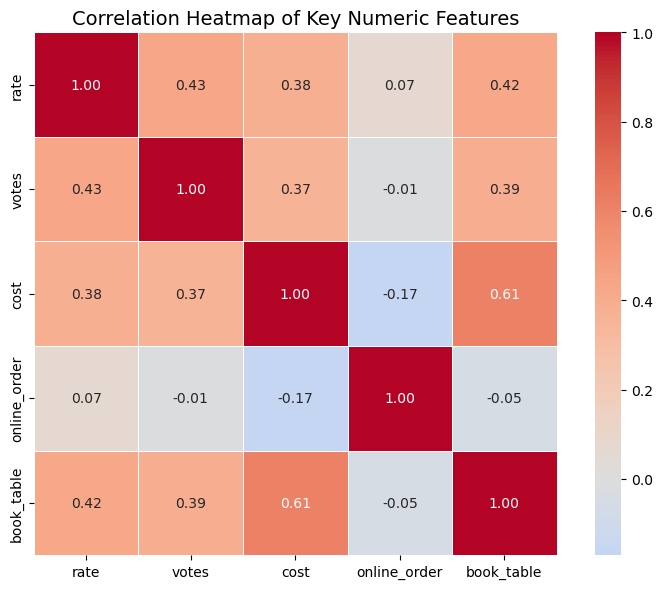

              rate  votes  cost  online_order  book_table
rate          1.00   0.43  0.38          0.07        0.42
votes         0.43   1.00  0.37         -0.01        0.39
cost          0.38   0.37  1.00         -0.17        0.61
online_order  0.07  -0.01 -0.17          1.00       -0.05
book_table    0.42   0.39  0.61         -0.05        1.00


In [10]:
# Create a numeric-only DataFrame for correlation
df_corr = df[['rate', 'votes', 'cost']].copy()

# Add binary columns for online_order and book_table
# We convert Yes/No text to 1/0 numbers so they can be correlated
df_corr['online_order'] = (df['online_order'] == 'Yes').astype(int)
df_corr['book_table']   = (df['book_table'] == 'Yes').astype(int)

# Drop rows with any missing value (rate has NaNs)
df_corr = df_corr.dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            square=True)

plt.title('Correlation Heatmap of Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

print(corr_matrix.round(2))